In [1]:
# uv 프로젝트 환경이 있으면 uv sync로 의존성 설치 (권장)
!pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pingouin scikit_posthocs xgboost -q
print("pip 설치 완료!")

pip 설치 완료!



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)



라이브러리 로드 완료!
한글 폰트 설정 완료!


In [3]:
df = pd.read_csv('2019-Nov_smartphone_preprocessed_final.csv')

In [4]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,is_price_error,hour,day_of_week,day_name,time_segment,is_outlier,is_purchase,is_cart
0,2019-11-01 09:00:00,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33,False,9,4,Friday,오전 (6-12시),False,0,0
1,2019-11-01 09:00:01,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2,False,9,4,Friday,오전 (6-12시),False,0,0
2,2019-11-01 09:00:02,view,1004258,2053013555631882655,electronics.smartphone,apple,732.07,532647354,d2d3d2c6-631d-489e-9fb5-06f340b85be0,False,9,4,Friday,오전 (6-12시),False,0,0
3,2019-11-01 09:00:07,view,1004566,2053013555631882655,electronics.smartphone,huawei,164.84,566265908,52c2c76c-b79e-4794-86ff-badc76d35f5a,False,9,4,Friday,오전 (6-12시),False,0,0
4,2019-11-01 09:00:08,view,1004708,2053013555631882655,electronics.smartphone,huawei,151.99,566143627,aa610ab3-5c60-4551-8a2b-8c999dddf843,False,9,4,Friday,오전 (6-12시),False,0,0


In [5]:
df['category_main'] = df['category_code'].str.split('.').str[0]
df['category_sub'] = df['category_code'].str.split('.').str[1]

print(df['category_main'].unique)
print(df['category_sub'].unique)

<bound method Series.unique of 0           electronics
1           electronics
2           electronics
3           electronics
4           electronics
               ...     
16324399    electronics
16324400    electronics
16324401    electronics
16324402    electronics
16324403    electronics
Name: category_main, Length: 16324404, dtype: object>
<bound method Series.unique of 0           smartphone
1           smartphone
2           smartphone
3           smartphone
4           smartphone
               ...    
16324399    smartphone
16324400    smartphone
16324401    smartphone
16324402    smartphone
16324403    smartphone
Name: category_sub, Length: 16324404, dtype: object>


In [6]:
df['category_code'].value_counts()

category_code
electronics.smartphone    16324404
Name: count, dtype: int64

In [7]:
df[df['category_code'] == 'electronics.smartphone']['brand'].value_counts()

brand
samsung       5294370
apple         4643814
xiaomi        3324299
huawei        1235245
oppo           809767
meizu          201548
vivo           159001
oneplus        110092
honor          107763
nokia           94080
sony            79839
tp-link         29394
bq              27358
lg              24195
inoi            22542
doogee          21558
unknown         21346
google          18757
umi             16527
prestigio       14596
haier           13186
zte              9961
tecno            7195
htc              6610
blackberry       4705
asus             4020
gionee           3626
jinga            3447
irbis            3213
nubia            3011
fly              2277
texet            1686
leeco            1604
vertex           1343
philips           681
oukitel           519
micromax          506
lenovo            407
leagoo            210
hiper              48
ark                42
motorola           15
bravis              1
Name: count, dtype: int64

In [8]:
df[df['category_code'] == 'electronics.smartphone']['brand'].value_counts(normalize=True) * 100

brand
samsung       32.432241
apple         28.447066
xiaomi        20.363984
huawei         7.566861
oppo           4.960469
meizu          1.234642
vivo           0.974008
oneplus        0.674401
honor          0.660134
nokia          0.576315
sony           0.489078
tp-link        0.180062
bq             0.167590
lg             0.148214
inoi           0.138088
doogee         0.132060
unknown        0.130761
google         0.114902
umi            0.101241
prestigio      0.089412
haier          0.080775
zte            0.061019
tecno          0.044075
htc            0.040492
blackberry     0.028822
asus           0.024626
gionee         0.022212
jinga          0.021116
irbis          0.019682
nubia          0.018445
fly            0.013948
texet          0.010328
leeco          0.009826
vertex         0.008227
philips        0.004172
oukitel        0.003179
micromax       0.003100
lenovo         0.002493
leagoo         0.001286
hiper          0.000294
ark            0.000257
motorola  

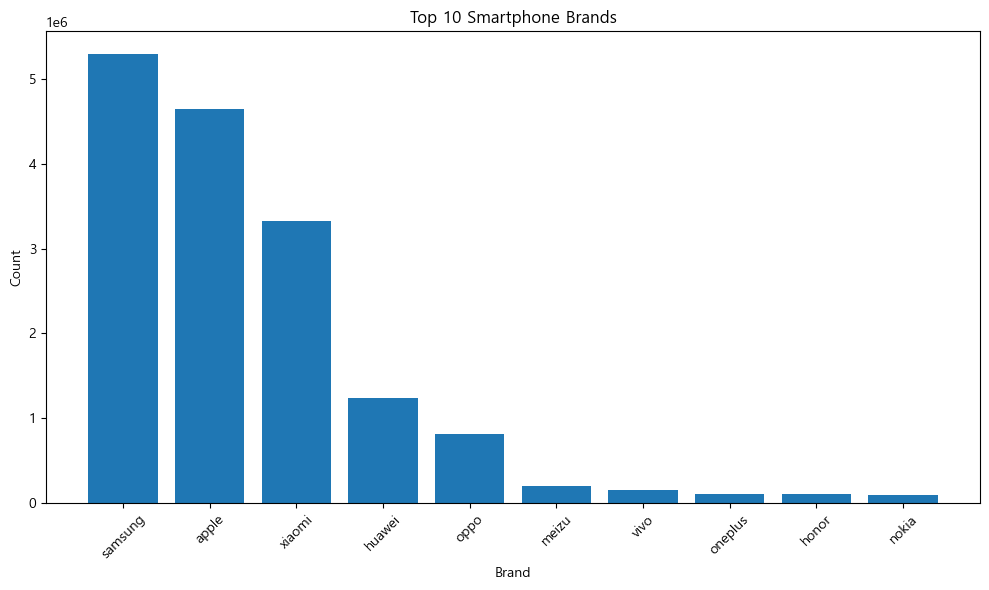

In [9]:
top_brands = df[df['category_code'] == 'electronics.smartphone']['brand'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_brands.index, top_brands.values)
plt.title('Top 10 Smartphone Brands')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
#이벤트 타입 변환

df['event_time'] = pd.to_datetime(df['event_time'], utc=True).dt.tz_convert('Asia/Seoul').dt.tz_localize(None)

In [11]:
df['hour'] = df['event_time'].dt.hour
df['day_of_week'] = df['event_time'].dt.dayofweek  # 0=월요일, 6=일요일
df['day_name'] = df['event_time'].dt.day_name()

# 구매(purchase) 이벤트만 필터링 (event_type 컬럼이 있다면)
purchases = df[df['event_type'] == 'purchase']

# 시간대별 집계
hourly = purchases.groupby('hour').size().reset_index(name='count')
print(hourly)

    hour  count
0      0  24062
1      1  25131
2      2  27904
3      3  30402
4      4  29238
5      5  27212
6      6  25248
7      7  24626
8      8  23871
9      9  20745
10    10  17821
11    11  16436
12    12  10163
13    13   7362
14    14   4577
15    15   2974
16    16   2100
17    17   1297
18    18   1194
19    19   1732
20    20   4360
21    21  10956
22    22  17878
23    23  22255


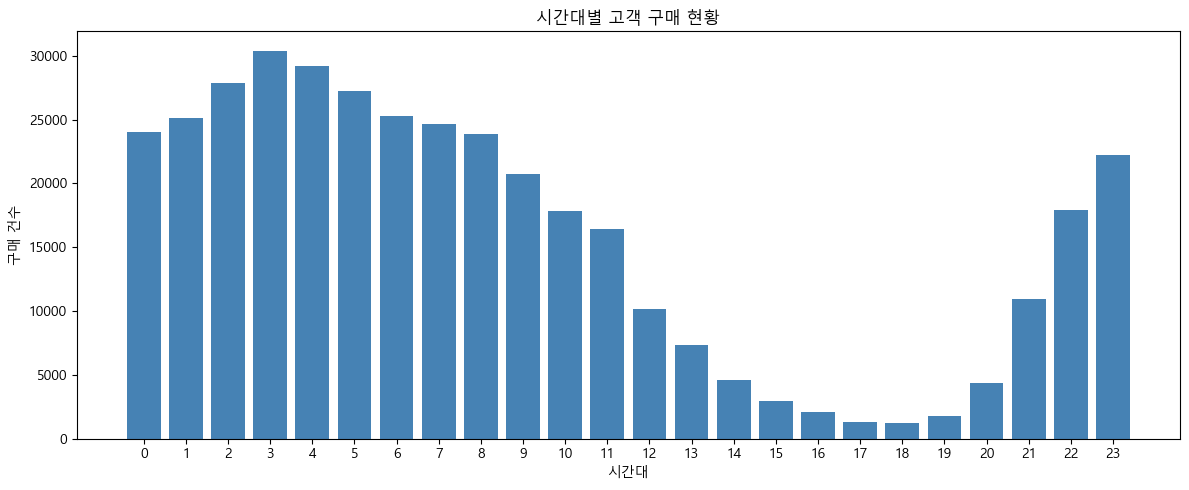

In [12]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 시간대별 막대 그래프
plt.figure(figsize=(12, 5))
plt.bar(hourly['hour'], hourly['count'], color='steelblue')
plt.xlabel('시간대')
plt.ylabel('구매 건수')
plt.title('시간대별 고객 구매 현황')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [13]:
def time_segment(hour):
    if 6 <= hour < 12:
        return '오전 (6-12시)'
    elif 12 <= hour < 18:
        return '오후 (12-18시)'
    elif 18 <= hour < 24:
        return '저녁 (18-24시)'
    else:
        return '새벽 (0-6시)'

purchases['time_segment'] = purchases['hour'].apply(time_segment)
print(purchases['time_segment'].value_counts())

time_segment
새벽 (0-6시)      163949
오전 (6-12시)     128747
저녁 (18-24시)     58375
오후 (12-18시)     28473
Name: count, dtype: int64


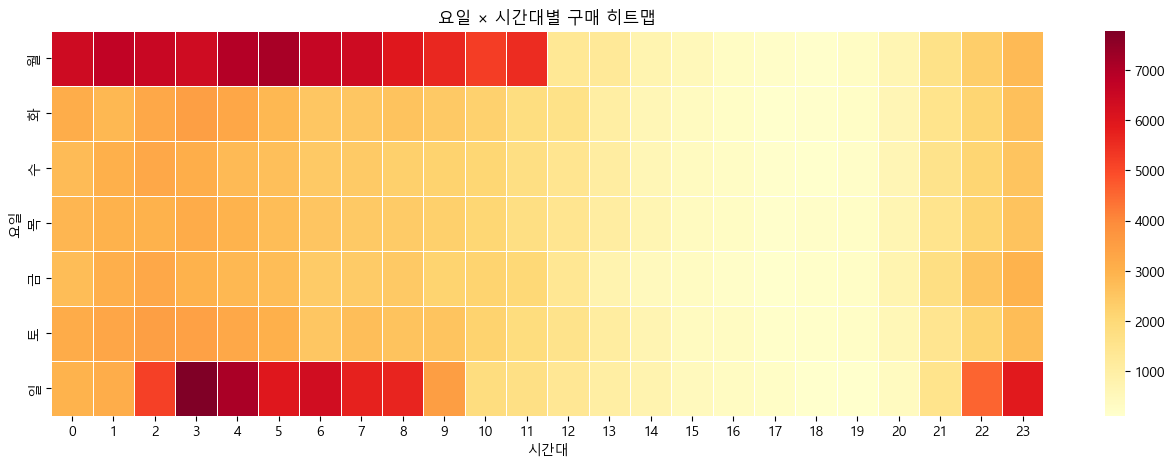

In [14]:
import seaborn as sns

heatmap_data = purchases.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
heatmap_data.index = ['월', '화', '수', '목', '금', '토', '일']

plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5)
plt.title('요일 × 시간대별 구매 히트맵')
plt.xlabel('시간대')
plt.ylabel('요일')
plt.show()

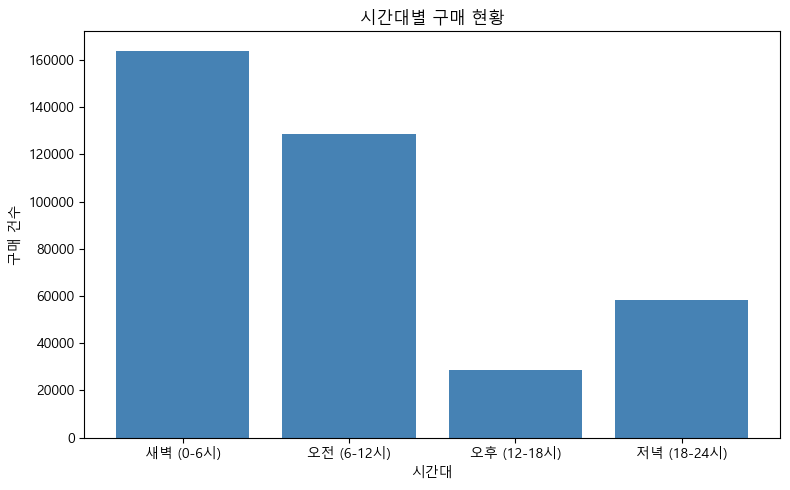

In [15]:

# 구매 이벤트 필터링 & 시간대 구간 추출
purchases = df[df['event_type'] == 'purchase'].copy()
purchases['hour'] = purchases['event_time'].dt.hour
purchases['time_segment'] = purchases['hour'].apply(time_segment)

# 순서 지정
segment_order = ['새벽 (0-6시)', '오전 (6-12시)', '오후 (12-18시)', '저녁 (18-24시)']
segment_counts = purchases['time_segment'].value_counts().reindex(segment_order)

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(segment_counts.index, segment_counts.values, color='steelblue')
plt.xlabel('시간대')
plt.ylabel('구매 건수')
plt.title('시간대별 구매 현황')
plt.tight_layout()
plt.show()

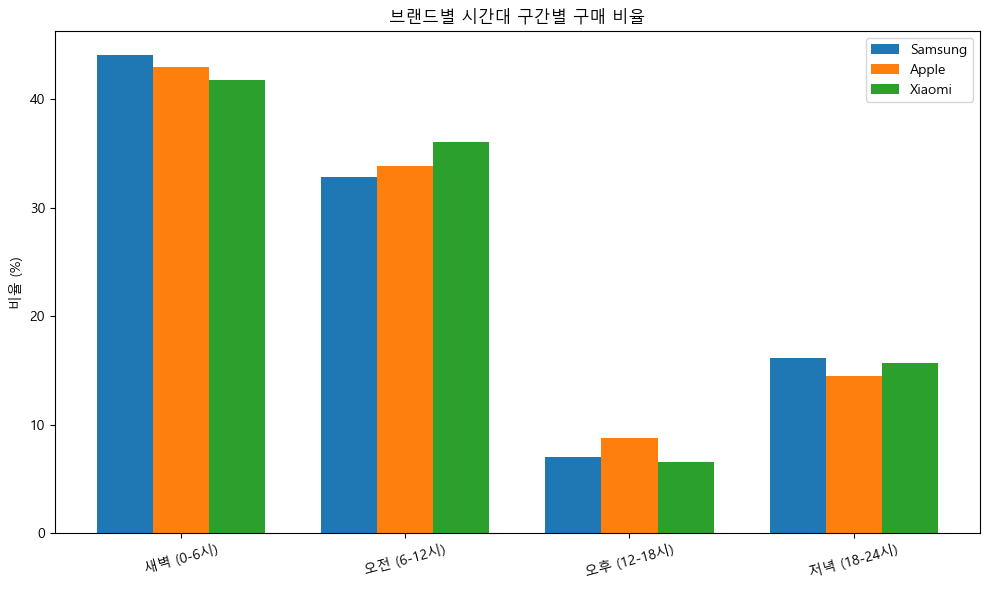

In [16]:
target_brands = ['samsung', 'apple', 'xiaomi']
colors = {'samsung': '#1f77b4', 'apple': '#ff7f0e', 'xiaomi': '#2ca02c'}
segment_order = ['새벽 (0-6시)', '오전 (6-12시)', '오후 (12-18시)', '저녁 (18-24시)']

# 타겟 브랜드 필터링 (purchases는 이미 위에서 만들어진 것 사용)
purchases_brand = purchases[purchases['brand'].isin(target_brands)]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(segment_order))
width = 0.25

for i, brand in enumerate(target_brands):
    data = purchases_brand[purchases_brand['brand'] == brand]['time_segment']
    ratio = data.value_counts().reindex(segment_order) / len(data) * 100
    ax.bar(x + i * width, ratio.values, width,
           label=brand.capitalize(), color=colors[brand])

ax.set_xticks(x + width)
ax.set_xticklabels(segment_order, rotation=15)
ax.set_ylabel('비율 (%)')
ax.set_title('브랜드별 시간대 구간별 구매 비율')
ax.legend()

plt.tight_layout()
plt.show()

In [17]:
#구매 전환 소요 시간 계산

# 구매가 있는 세션만 필터링
sessions_with_purchase = df[df['event_type'] == 'purchase']['user_session'].unique()
df_filtered = df[df['user_session'].isin(sessions_with_purchase)]

# 세션별 첫 view 시간
first_view = (
    df_filtered[df_filtered['event_type'] == 'view']
    .groupby('user_session')['event_time']
    .min()
    .rename('first_view_time')
)

# 세션별 첫 purchase 시간
first_purchase = (
    df_filtered[df_filtered['event_type'] == 'purchase']
    .groupby('user_session')['event_time']
    .min()
    .rename('first_purchase_time')
)

# 합치기
conversion = pd.concat([first_view, first_purchase], axis=1).dropna()

# 전환까지 걸린 시간 (분 단위)
conversion['conversion_minutes'] = (
    conversion['first_purchase_time'] - conversion['first_view_time']
).dt.total_seconds() / 60

# view가 purchase보다 늦은 이상한 케이스 제거
conversion = conversion[conversion['conversion_minutes'] >= 0]

print(conversion['conversion_minutes'].describe())

count    318012.000000
mean          5.954038
std          88.164535
min           0.083333
25%           1.266667
50%           2.600000
75%           5.383333
max       33167.033333
Name: conversion_minutes, dtype: float64


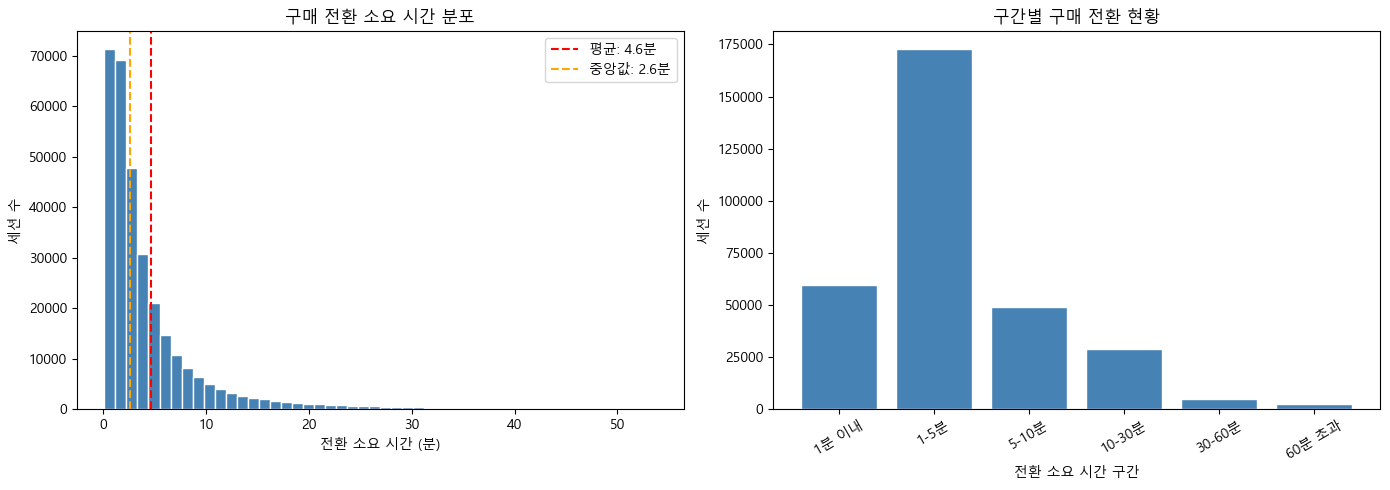

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 이상치 제거 (상위 1%)
upper = conversion['conversion_minutes'].quantile(0.99)
data = conversion[conversion['conversion_minutes'] <= upper]['conversion_minutes']

# 1. 분포 히스토그램
axes[0].hist(data, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(data.mean(), color='red', linestyle='--', label=f'평균: {data.mean():.1f}분')
axes[0].axvline(data.median(), color='orange', linestyle='--', label=f'중앙값: {data.median():.1f}분')
axes[0].set_xlabel('전환 소요 시간 (분)')
axes[0].set_ylabel('세션 수')
axes[0].set_title('구매 전환 소요 시간 분포')
axes[0].legend()

# 2. 구간별 막대 그래프
bins = [0, 1, 5, 10, 30, 60, float('inf')]
labels = ['1분 이내', '1-5분', '5-10분', '10-30분', '30-60분', '60분 초과']
conversion['time_bucket'] = pd.cut(conversion['conversion_minutes'], bins=bins, labels=labels)
bucket_counts = conversion['time_bucket'].value_counts().reindex(labels)

axes[1].bar(bucket_counts.index, bucket_counts.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('전환 소요 시간 구간')
axes[1].set_ylabel('세션 수')
axes[1].set_title('구간별 구매 전환 현황')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

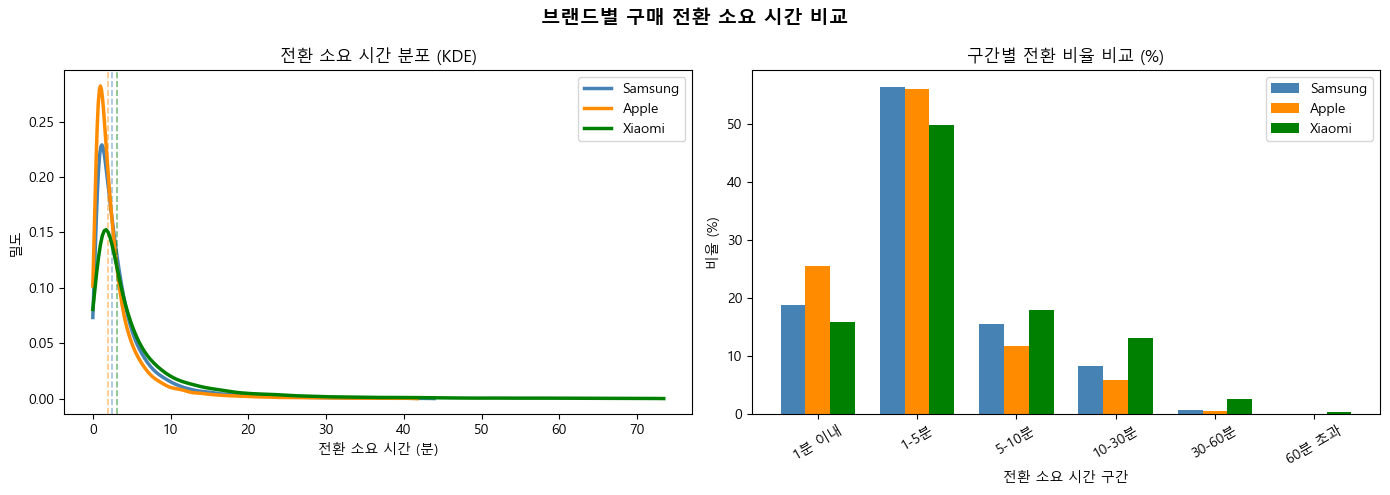

In [19]:
# 브랜드별 데이터 한 번에 만들기
target_brands = ['samsung', 'apple', 'xiaomi']
colors = {'samsung': 'steelblue', 'apple': 'darkorange', 'xiaomi': 'green'}

brand_conv = {}

for brand in target_brands:
    brand_df = df[df['brand'] == brand]
    sessions_with_purchase = brand_df[brand_df['event_type'] == 'purchase']['user_session'].unique()
    df_filtered = brand_df[brand_df['user_session'].isin(sessions_with_purchase)]

    first_view = (
        df_filtered[df_filtered['event_type'] == 'view']
        .groupby('user_session')['event_time'].min()
        .rename('first_view_time')
    )
    first_purchase = (
        df_filtered[df_filtered['event_type'] == 'purchase']
        .groupby('user_session')['event_time'].min()
        .rename('first_purchase_time')
    )

    conv = pd.concat([first_view, first_purchase], axis=1).dropna()
    conv['conversion_minutes'] = (
        conv['first_purchase_time'] - conv['first_view_time']
    ).dt.total_seconds() / 60
    conv = conv[conv['conversion_minutes'] >= 0]
    upper = conv['conversion_minutes'].quantile(0.99)
    brand_conv[brand] = conv[conv['conversion_minutes'] <= upper]['conversion_minutes']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('브랜드별 구매 전환 소요 시간 비교', fontsize=14, fontweight='bold')

# 왼쪽: KDE 분포 비교
from scipy.stats import gaussian_kde
import numpy as np

for brand, data in brand_conv.items():
    kde = gaussian_kde(data)
    x = np.linspace(0, data.max(), 300)
    axes[0].plot(x, kde(x), label=brand.capitalize(),
                 color=colors[brand], linewidth=2.5)
    axes[0].axvline(data.median(), color=colors[brand],
                    linestyle='--', alpha=0.5, linewidth=1.2)

axes[0].set_title('전환 소요 시간 분포 (KDE)')
axes[0].set_xlabel('전환 소요 시간 (분)')
axes[0].set_ylabel('밀도')
axes[0].legend()

# 오른쪽: 구간별 비율 비교 (건수보다 비율이 브랜드 간 비교에 유리)
bins_  = [0, 1, 5, 10, 30, 60, float('inf')]
labels_ = ['1분 이내', '1-5분', '5-10분', '10-30분', '30-60분', '60분 초과']
x = np.arange(len(labels_))
width = 0.25

for i, (brand, data) in enumerate(brand_conv.items()):
    buckets = pd.cut(data, bins=bins_, labels=labels_)
    ratio = buckets.value_counts().reindex(labels_) / len(data) * 100
    axes[1].bar(x + i * width, ratio.values, width,
                label=brand.capitalize(), color=colors[brand])

axes[1].set_title('구간별 전환 비율 비교 (%)')
axes[1].set_xlabel('전환 소요 시간 구간')
axes[1].set_ylabel('비율 (%)')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(labels_, rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
# 1. 세션별 첫 view의 price 가져오기
first_view_price = (
    df_filtered[df_filtered['event_type'] == 'view']
    .groupby('user_session')
    .apply(lambda x: x.loc[x['event_time'].idxmin(), 'price'])
    .rename('price')
)

# 2. 기존 price 컬럼 있으면 제거 후 합치기
conversion = conversion.drop(columns=['price'], errors='ignore')
conversion = conversion.join(first_view_price)

# 3. 가격대 구간
bins = [0, 50, 150, 300, 500, 1000, float('inf')]
labels = ['~$50', '$50-150', '$150-300', '$300-500', '$500-1000', '$1000+']

conversion['price_bucket'] = pd.cut(conversion['price'], bins=bins, labels=labels)

# 4. 구간별 평균/중앙값 전환 시간
price_conversion = conversion.groupby('price_bucket')['conversion_minutes'].agg(
    평균='mean',
    중앙값='median',
    건수='count'
).reset_index()

print(price_conversion)

  price_bucket         평균       중앙값     건수
0      $50-150   8.893977  3.850000  11544
1     $150-300   8.199298  3.383333  27149
2     $300-500   8.565910  2.933333   3614
3    $500-1000  12.120725  5.033333    115


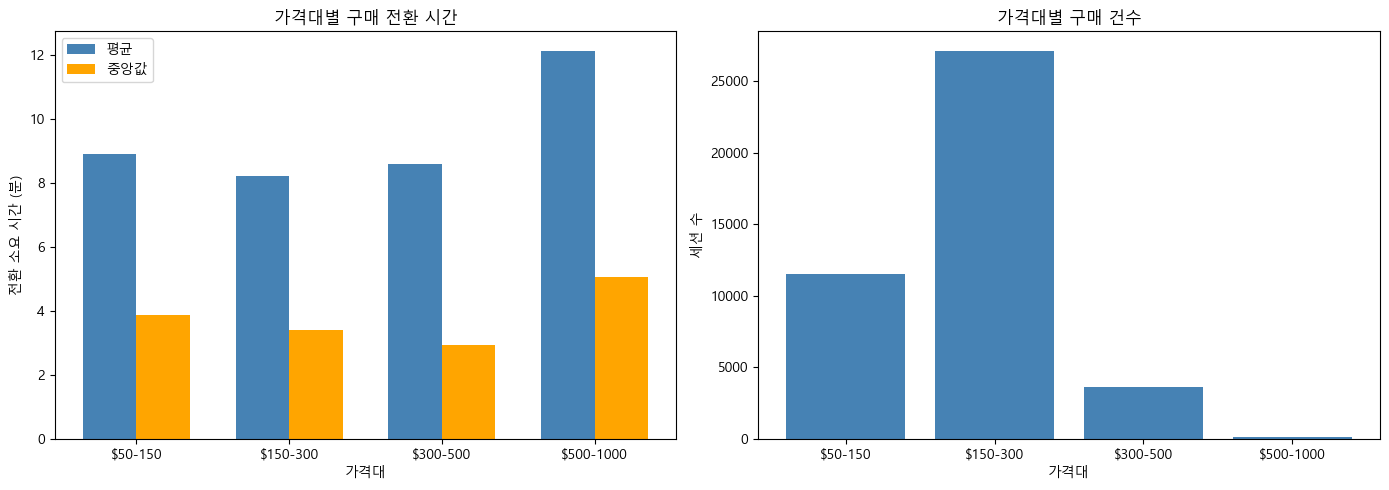

In [21]:
# 5. 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 평균 vs 중앙값 전환 시간
x = range(len(price_conversion))
width = 0.35

axes[0].bar([i - width/2 for i in x], price_conversion['평균'], width=width, label='평균', color='steelblue')
axes[0].bar([i + width/2 for i in x], price_conversion['중앙값'], width=width, label='중앙값', color='orange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(price_conversion['price_bucket'])
axes[0].set_xlabel('가격대')
axes[0].set_ylabel('전환 소요 시간 (분)')
axes[0].set_title('가격대별 구매 전환 시간')
axes[0].legend()

# 가격대별 건수
axes[1].bar(price_conversion['price_bucket'], price_conversion['건수'], color='steelblue')
axes[1].set_xlabel('가격대')
axes[1].set_ylabel('세션 수')
axes[1].set_title('가격대별 구매 건수')

plt.tight_layout()
plt.show()

In [22]:
print(conversion['price'].describe())
print(conversion['price'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count    42422.000000
mean       203.029985
std         82.005254
min         66.350000
25%        145.380000
50%        198.640000
75%        224.970000
max        738.760000
Name: price, dtype: float64
0.25    145.38
0.50    198.64
0.75    224.97
0.90    288.04
0.95    369.11
0.99    463.07
Name: price, dtype: float64


In [23]:
# 1. 첫 view 시간에서 시간대 추출
conversion['hour'] = conversion['first_purchase_time'].dt.hour
conversion['time_segment'] = conversion['hour'].apply(time_segment)

# 2. 시간대별 평균/중앙값 전환 시간
segment_order = ['새벽 (0-6시)', '오전 (6-12시)', '오후 (12-18시)', '저녁 (18-24시)']
time_conversion = conversion.groupby('time_segment')['conversion_minutes'].agg(
    평균='mean',
    중앙값='median',
    건수='count'
).reindex(segment_order).reset_index()

print(time_conversion)

  time_segment        평균       중앙값      건수
0    새벽 (0-6시)  5.840084  2.550000  136159
1   오전 (6-12시)  6.469822  2.850000  108152
2  오후 (12-18시)  6.559620  2.283333   23504
3  저녁 (18-24시)  4.868301  2.383333   50197


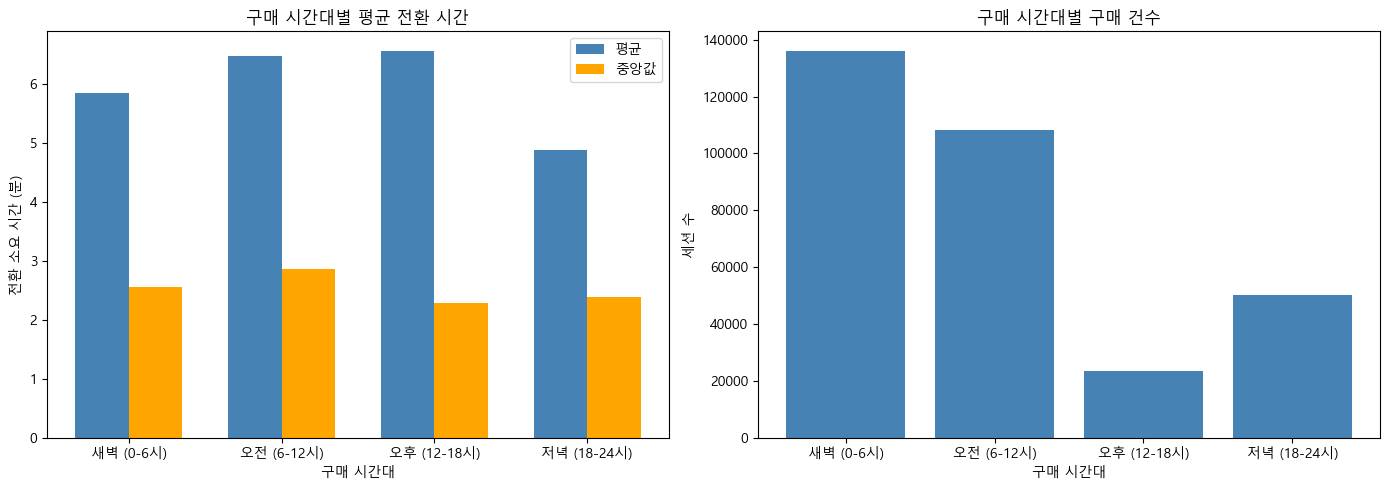

In [24]:
# 3. 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 평균 vs 중앙값 전환 시간
x = range(len(time_conversion))
width = 0.35

axes[0].bar([i - width/2 for i in x], time_conversion['평균'], width=width, label='평균', color='steelblue')
axes[0].bar([i + width/2 for i in x], time_conversion['중앙값'], width=width, label='중앙값', color='orange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(time_conversion['time_segment'])
axes[0].set_xlabel('구매 시간대')
axes[0].set_ylabel('전환 소요 시간 (분)')
axes[0].set_title('구매 시간대별 평균 전환 시간')
axes[0].legend()

# 시간대별 구매 건수
axes[1].bar(time_conversion['time_segment'], time_conversion['건수'], color='steelblue')
axes[1].set_xlabel('구매 시간대')
axes[1].set_ylabel('세션 수')
axes[1].set_title('구매 시간대별 구매 건수')

plt.tight_layout()
plt.show()

In [25]:
# 1. 세션별 구매 브랜드 가져오기
first_purchase_brand = (
    df_filtered[df_filtered['event_type'] == 'purchase']
    .groupby('user_session')
    .apply(lambda x: x.loc[x['event_time'].idxmin(), 'brand'])
    .rename('brand')
)

# 2. conversion 테이블에 brand 합치기
conversion = conversion.drop(columns=['brand'], errors='ignore')
conversion = conversion.join(first_purchase_brand)

# 3. 브랜드별 평균/중앙값 전환 시간 (건수 50건 이상만)
brand_conversion = (
    conversion.groupby('brand')['conversion_minutes']
    .agg(평균='mean', 중앙값='median', 건수='count')
    .reset_index()
)
brand_conversion = brand_conversion[brand_conversion['건수'] >= 50]

print(f"브랜드 수: {len(brand_conversion)}")
print(brand_conversion.sort_values('평균').head(10))  # 전환 빠른 상위 10개
print(brand_conversion.sort_values('평균').tail(10))  # 전환 느린 상위 10개

브랜드 수: 1
    brand        평균       중앙값     건수
0  xiaomi  8.430195  3.466667  42448
    brand        평균       중앙값     건수
0  xiaomi  8.430195  3.466667  42448


In [26]:
# 1. 스마트폰 카테고리의 구매 세션만 필터링
smartphone_sessions = df_filtered[
    (df_filtered['event_type'] == 'purchase') &
    (df_filtered['category_code'] == 'electronics.smartphone')
]['user_session'].unique()

df_smartphone = df_filtered[df_filtered['user_session'].isin(smartphone_sessions)]

# 2. 세션별 구매 브랜드 가져오기
first_purchase_brand = (
    df_smartphone[df_smartphone['event_type'] == 'purchase']
    .groupby('user_session')
    .apply(lambda x: x.loc[x['event_time'].idxmin(), 'brand'])
    .rename('brand')
)

# 3. conversion 테이블에 brand 합치기
conversion_smartphone = conversion[conversion.index.isin(smartphone_sessions)].copy()
conversion_smartphone = conversion_smartphone.drop(columns=['brand'], errors='ignore')
conversion_smartphone = conversion_smartphone.join(first_purchase_brand)

# 4. 브랜드별 평균/중앙값 전환 시간 (건수 50건 이상만)
brand_conversion = (
    conversion_smartphone.groupby('brand')['conversion_minutes']
    .agg(평균='mean', 중앙값='median', 건수='count')
    .reset_index()
)
brand_conversion = brand_conversion[brand_conversion['건수'] >= 50]

print(f"브랜드 수: {len(brand_conversion)}")
print(brand_conversion.sort_values('평균'))

브랜드 수: 1
    brand        평균       중앙값     건수
0  xiaomi  8.430195  3.466667  42448


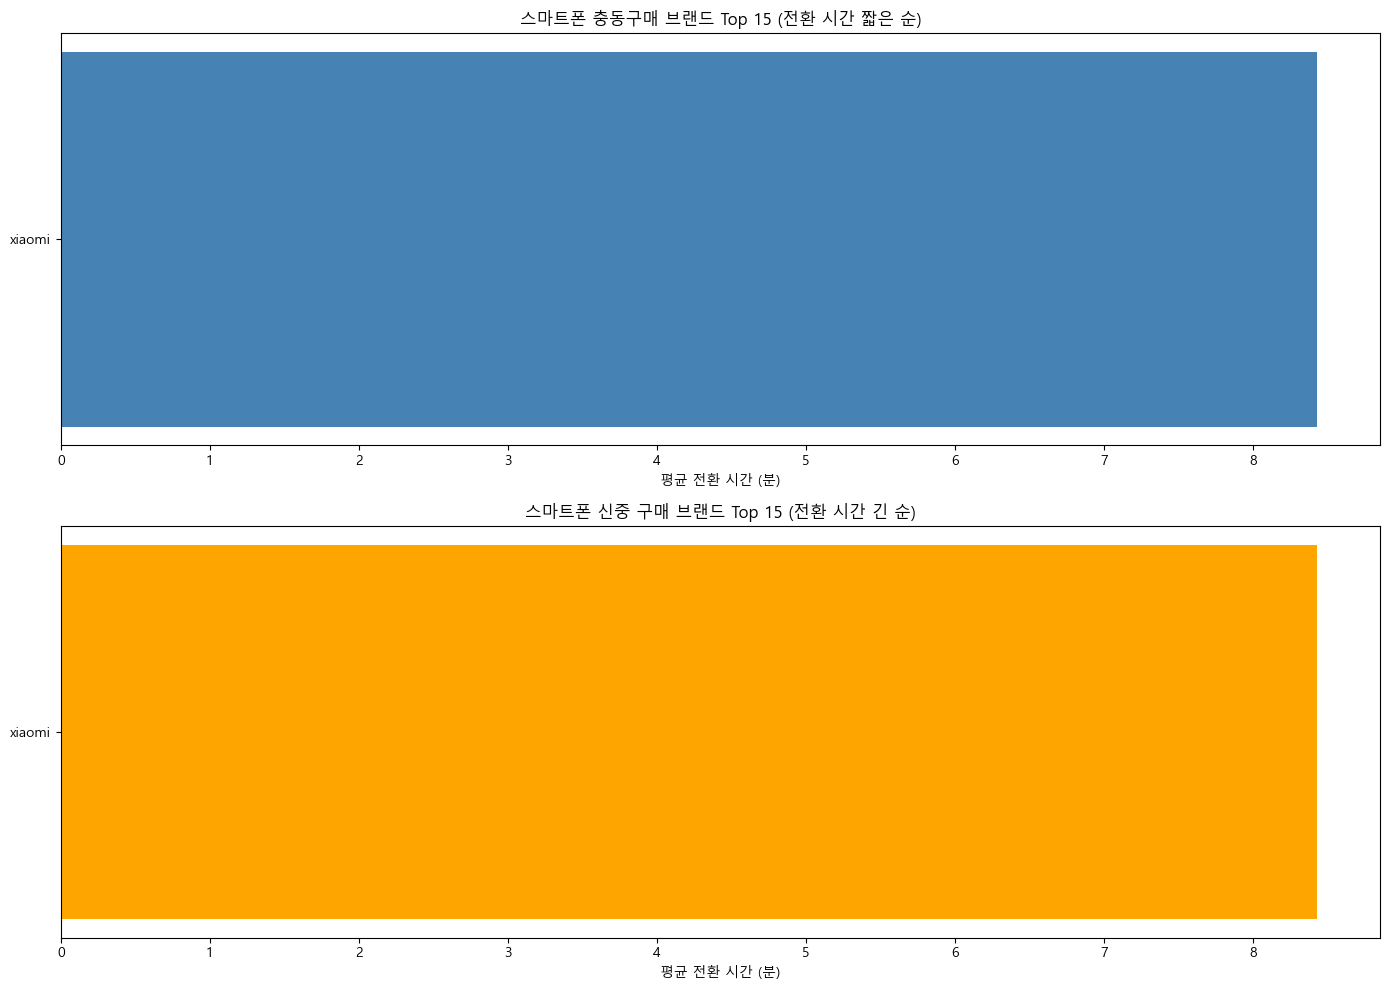

In [27]:
# 5. 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

top_fast = brand_conversion.nsmallest(15, '평균')
top_slow = brand_conversion.nlargest(15, '평균')

axes[0].barh(top_fast['brand'], top_fast['평균'], color='steelblue')
axes[0].set_xlabel('평균 전환 시간 (분)')
axes[0].set_title('스마트폰 충동구매 브랜드 Top 15 (전환 시간 짧은 순)')
axes[0].invert_yaxis()

axes[1].barh(top_slow['brand'], top_slow['평균'], color='orange')
axes[1].set_xlabel('평균 전환 시간 (분)')
axes[1].set_title('스마트폰 신중 구매 브랜드 Top 15 (전환 시간 긴 순)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [28]:
import matplotlib.pyplot as plt

# 1. 전자제품 세션 필터링
electronics_sessions = df_filtered[
    (df_filtered['event_type'] == 'purchase') &
    (df_filtered['category_code'].str.contains('electronics', na=False))
]['user_session'].unique()

df_electronics = df_filtered[df_filtered['user_session'].isin(electronics_sessions)]

# 2. 세션별 구매 브랜드 가져오기
first_purchase_brand = (
    df_electronics[df_electronics['event_type'] == 'purchase']
    .groupby('user_session')
    .apply(lambda x: x.loc[x['event_time'].idxmin(), 'brand'])
    .rename('brand')
)

# 3. conversion 테이블에 brand 합치기
conversion_electronics = conversion[conversion.index.isin(electronics_sessions)].copy()
conversion_electronics = conversion_electronics.drop(columns=['brand'], errors='ignore')
conversion_electronics = conversion_electronics.join(first_purchase_brand)

# 4. 브랜드별 집계 (건수 10건 이상만)
brand_conversion = (
    conversion_electronics.groupby('brand')['conversion_minutes']
    .agg(평균='mean', 중앙값='median', 건수='count')
    .reset_index()
)
brand_conversion = brand_conversion[brand_conversion['건수'] >= 10].sort_values('평균')

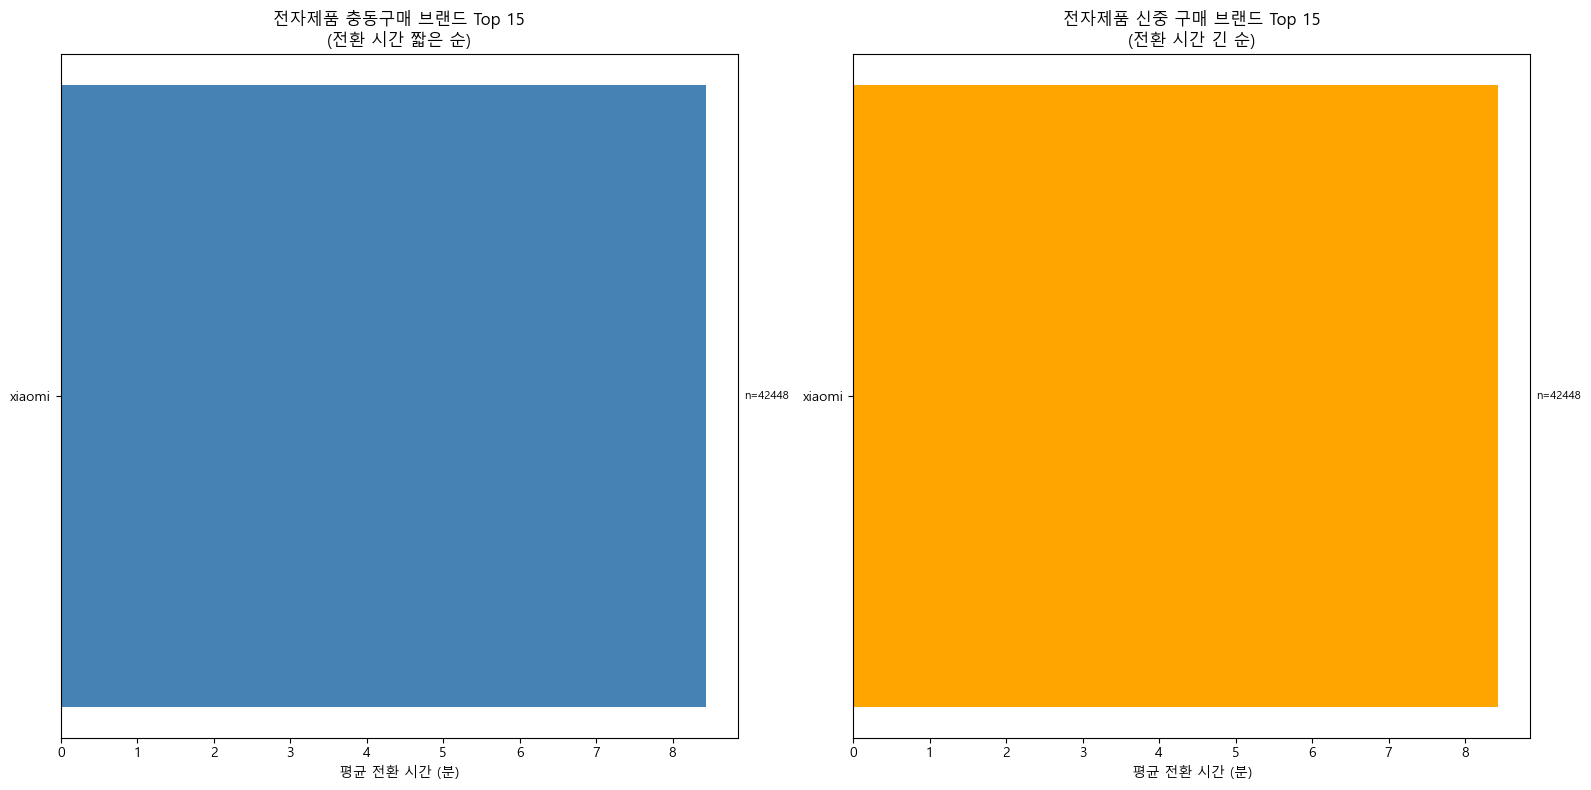

In [29]:

# 5. 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_fast = brand_conversion.nsmallest(15, '평균')
top_slow = brand_conversion.nlargest(15, '평균')

# 충동구매 브랜드
bars1 = axes[0].barh(top_fast['brand'], top_fast['평균'], color='steelblue')
axes[0].set_xlabel('평균 전환 시간 (분)')
axes[0].set_title('전자제품 충동구매 브랜드 Top 15\n(전환 시간 짧은 순)')
axes[0].invert_yaxis()
# 건수 표시
for bar, count in zip(bars1, top_fast['건수']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'n={count}', va='center', fontsize=8)

# 신중 구매 브랜드
bars2 = axes[1].barh(top_slow['brand'], top_slow['평균'], color='orange')
axes[1].set_xlabel('평균 전환 시간 (분)')
axes[1].set_title('전자제품 신중 구매 브랜드 Top 15\n(전환 시간 긴 순)')
axes[1].invert_yaxis()
# 건수 표시
for bar, count in zip(bars2, top_slow['건수']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'n={count}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [30]:
# 1. 세션별 view 횟수 집계
view_counts = (
    df_filtered[df_filtered['event_type'] == 'view']
    .groupby('user_session')
    .size()
    .rename('view_count')
)

# 2. conversion 테이블에 view 횟수 합치기
conversion = conversion.drop(columns=['view_count'], errors='ignore')
conversion = conversion.join(view_counts)

print(conversion['view_count'].describe())

count    42422.000000
mean         4.392014
std          5.344745
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max        137.000000
Name: view_count, dtype: float64


In [31]:
bins = [0, 1, 2, 3, 5, 10, float('inf')]
labels = ['1회', '2회', '3회', '4-5회', '6-10회', '11회+']

conversion['view_bucket'] = pd.cut(conversion['view_count'], bins=bins, labels=labels)

view_conversion = (
    conversion.groupby('view_bucket')['conversion_minutes']
    .agg(평균='mean', 중앙값='median', 건수='count')
    .reset_index()
)

print(view_conversion)

  view_bucket         평균        중앙값     건수
0          1회   3.343458   2.083333   9246
1          2회   3.615025   2.100000  10682
2          3회   6.101384   3.233333   6284
3        4-5회   8.115208   4.666667   6819
4       6-10회  15.242044   8.233333   5926
5        11회+  30.041419  18.850000   3465


In [32]:
bins = [0, 3, 6, 10, 20, float('inf')]
labels = ['1-3회', '4-6회', '7-10회', '11-20회', '21회+']

conversion['view_bucket'] = pd.cut(conversion['view_count'], bins=bins, labels=labels)

view_conversion = (
    conversion.groupby('view_bucket')['conversion_minutes']
    .agg(평균='mean', 중앙값='median', 건수='count')
    .reset_index()
)

print(view_conversion)

  view_bucket         평균        중앙값     건수
0        1-3회   4.115307   2.316667  26212
1        4-6회   8.867894   5.000000   8759
2       7-10회  17.056715   9.166667   3986
3      11-20회  24.099829  15.950000   2637
4        21회+  48.964090  33.166667    828


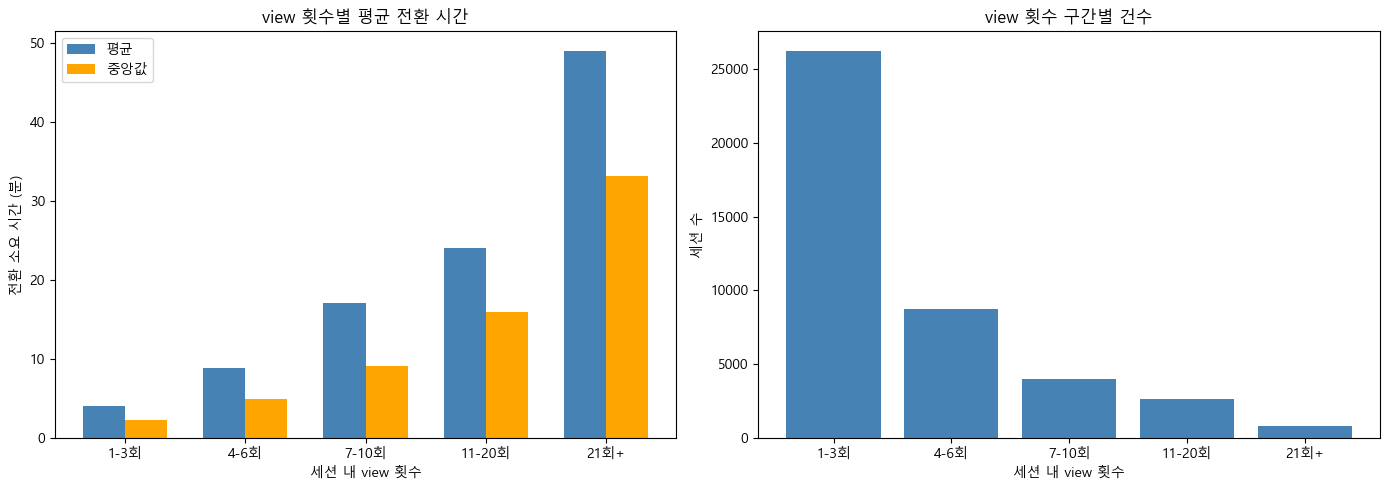

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(view_conversion))
width = 0.35

axes[0].bar([i - width/2 for i in x], view_conversion['평균'], width=width, label='평균', color='steelblue')
axes[0].bar([i + width/2 for i in x], view_conversion['중앙값'], width=width, label='중앙값', color='orange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(view_conversion['view_bucket'])
axes[0].set_xlabel('세션 내 view 횟수')
axes[0].set_ylabel('전환 소요 시간 (분)')
axes[0].set_title('view 횟수별 평균 전환 시간')
axes[0].legend()

axes[1].bar(view_conversion['view_bucket'], view_conversion['건수'], color='steelblue')
axes[1].set_xlabel('세션 내 view 횟수')
axes[1].set_ylabel('세션 수')
axes[1].set_title('view 횟수 구간별 건수')

plt.tight_layout()
plt.show()

추가 분석

In [34]:
# 1. 새 bins로 speed_group 생성
bins = [0, 1, 3, 10, 30, float('inf')]
labels = ['즉시(~1분)', '빠름(1-3분)', '탐색(3-10분)', '신중(10-30분)', '장기고민(30분+)']

conversion['speed_group'] = pd.cut(
    conversion['conversion_minutes'],
    bins=bins,
    labels=labels
)

# 2. group_profile 생성
group_profile = conversion.groupby('speed_group', observed=True).agg(
    세션수=('conversion_minutes', 'count'),
    평균전환시간=('conversion_minutes', 'mean'),
    평균가격=('price', 'mean'),
    중앙값가격=('price', 'median'),
).reset_index()

group_profile['비율(%)'] = (group_profile['세션수'] / group_profile['세션수'].sum() * 100).round(1)
print(group_profile)

  speed_group     세션수     평균전환시간        평균가격   중앙값가격  비율(%)
0     즉시(~1분)   59458   0.633535  211.404026  200.01   18.7
1    빠름(1-3분)  117398   1.894264  204.425285  198.95   36.9
2   탐색(3-10분)  104433   5.332800  200.121983  198.11   32.8
3  신중(10-30분)   29132  16.048173  197.994881  197.02    9.2
4  장기고민(30분+)    7591  80.222419  206.111118  199.66    2.4


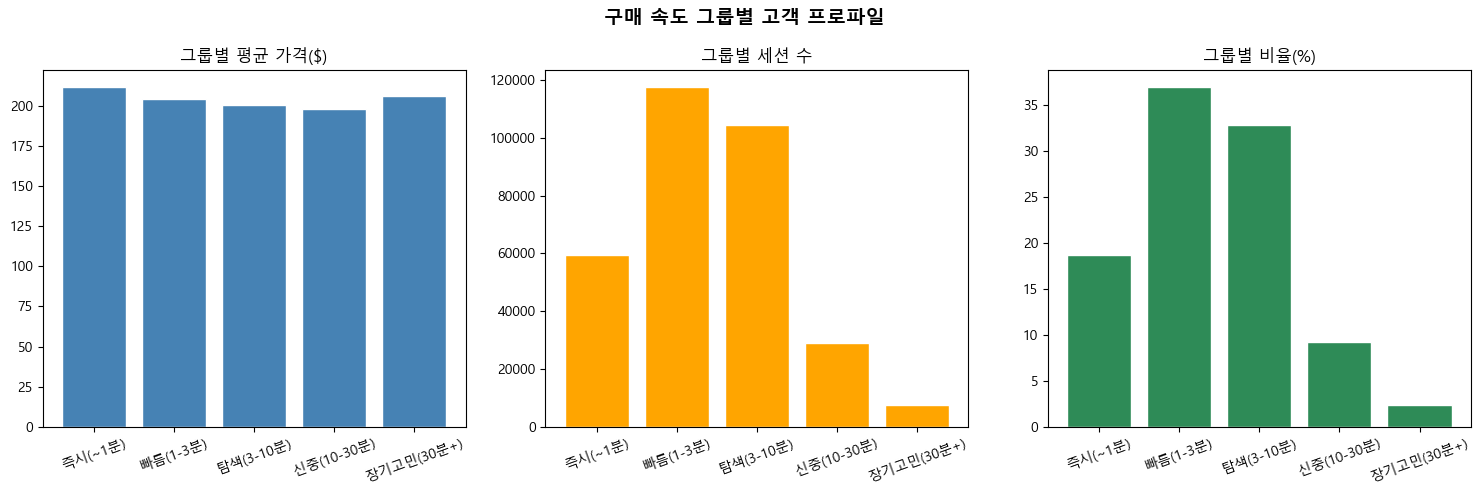

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['평균가격', '세션수', '비율(%)']
titles = ['그룹별 평균 가격($)', '그룹별 세션 수', '그룹별 비율(%)']
colors = ['steelblue', 'orange', 'seagreen']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.bar(group_profile['speed_group'], group_profile[metric], color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('구매 속도 그룹별 고객 프로파일', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
# 세션별 이벤트 타입 존재 여부 확인
session_events = df_filtered.groupby('user_session')['event_type'].apply(set).reset_index()
session_events.columns = ['user_session', 'event_set']

session_events['has_view']     = session_events['event_set'].apply(lambda x: 'view' in x)
session_events['has_cart']     = session_events['event_set'].apply(lambda x: 'cart' in x)
session_events['has_purchase'] = session_events['event_set'].apply(lambda x: 'purchase' in x)

# conversion 테이블에 합치기
conversion = conversion.join(
    session_events.set_index('user_session')[['has_view', 'has_cart', 'has_purchase']],
    on='user_session'  # conversion의 index가 user_session인 경우
)

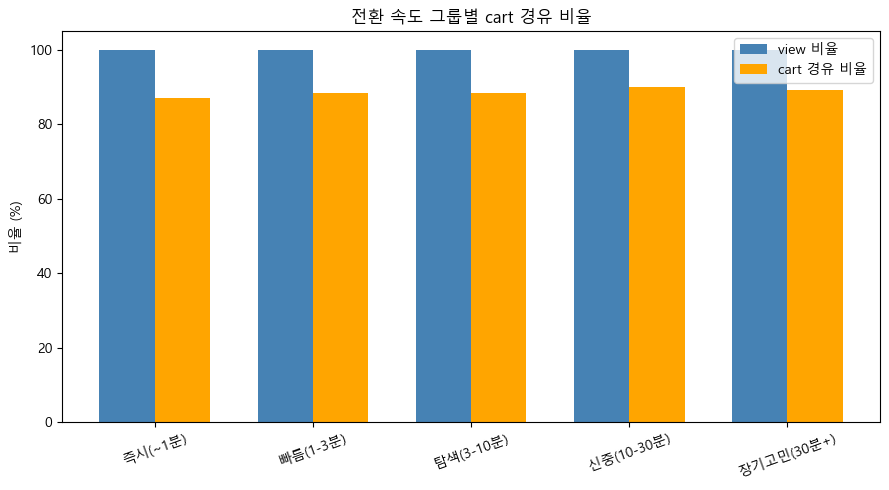

In [37]:
# 전환 속도 그룹별 cart 경유 비율
funnel_by_speed = conversion.groupby('speed_group').agg(
    view_비율=('has_view', 'mean'),
    cart_경유비율=('has_cart', 'mean'),
    세션수=('conversion_minutes', 'count')
).reset_index()

funnel_by_speed[['view_비율', 'cart_경유비율']] *= 100

# 시각화
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(funnel_by_speed))
width = 0.35

ax.bar([i - width/2 for i in x], funnel_by_speed['view_비율'],
       width=width, label='view 비율', color='steelblue')
ax.bar([i + width/2 for i in x], funnel_by_speed['cart_경유비율'],
       width=width, label='cart 경유 비율', color='orange')

ax.set_xticks(x)
ax.set_xticklabels(funnel_by_speed['speed_group'])
ax.set_ylabel('비율 (%)')
ax.set_title('전환 속도 그룹별 cart 경유 비율')
ax.legend()
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [38]:
print(group_profile[['speed_group', '세션수']])

  speed_group     세션수
0     즉시(~1분)   59458
1    빠름(1-3분)  117398
2   탐색(3-10분)  104433
3  신중(10-30분)   29132
4  장기고민(30분+)    7591


In [39]:

# 세션별 이벤트 타입별 횟수 집계
session_event_counts = (
    df_filtered.groupby(['user_session', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 컬럼명 정리 (없는 이벤트 타입 대비)
for col in ['view', 'cart', 'purchase']:
    if col not in session_event_counts.columns:
        session_event_counts[col] = 0

session_event_counts = session_event_counts.rename(columns={
    'view': 'view_count',
    'cart': 'cart_count',
    'purchase': 'purchase_count'
})

# 기존 컬럼 제거 후 다시 합치기
conversion = conversion.drop(columns=['view_count', 'cart_count', 'purchase_count'], errors='ignore')

# conversion에 합치기
conversion = conversion.join(
    session_event_counts.set_index('user_session')[['view_count', 'cart_count', 'purchase_count']],
    on='user_session'
)

# 구매 경로 패턴 정의
def classify_path(row):
    if row['cart_count'] == 0:
        return 'view→purchase (cart 스킵)'
    else:
        return 'view→cart→purchase'

conversion['purchase_path'] = conversion.apply(classify_path, axis=1)

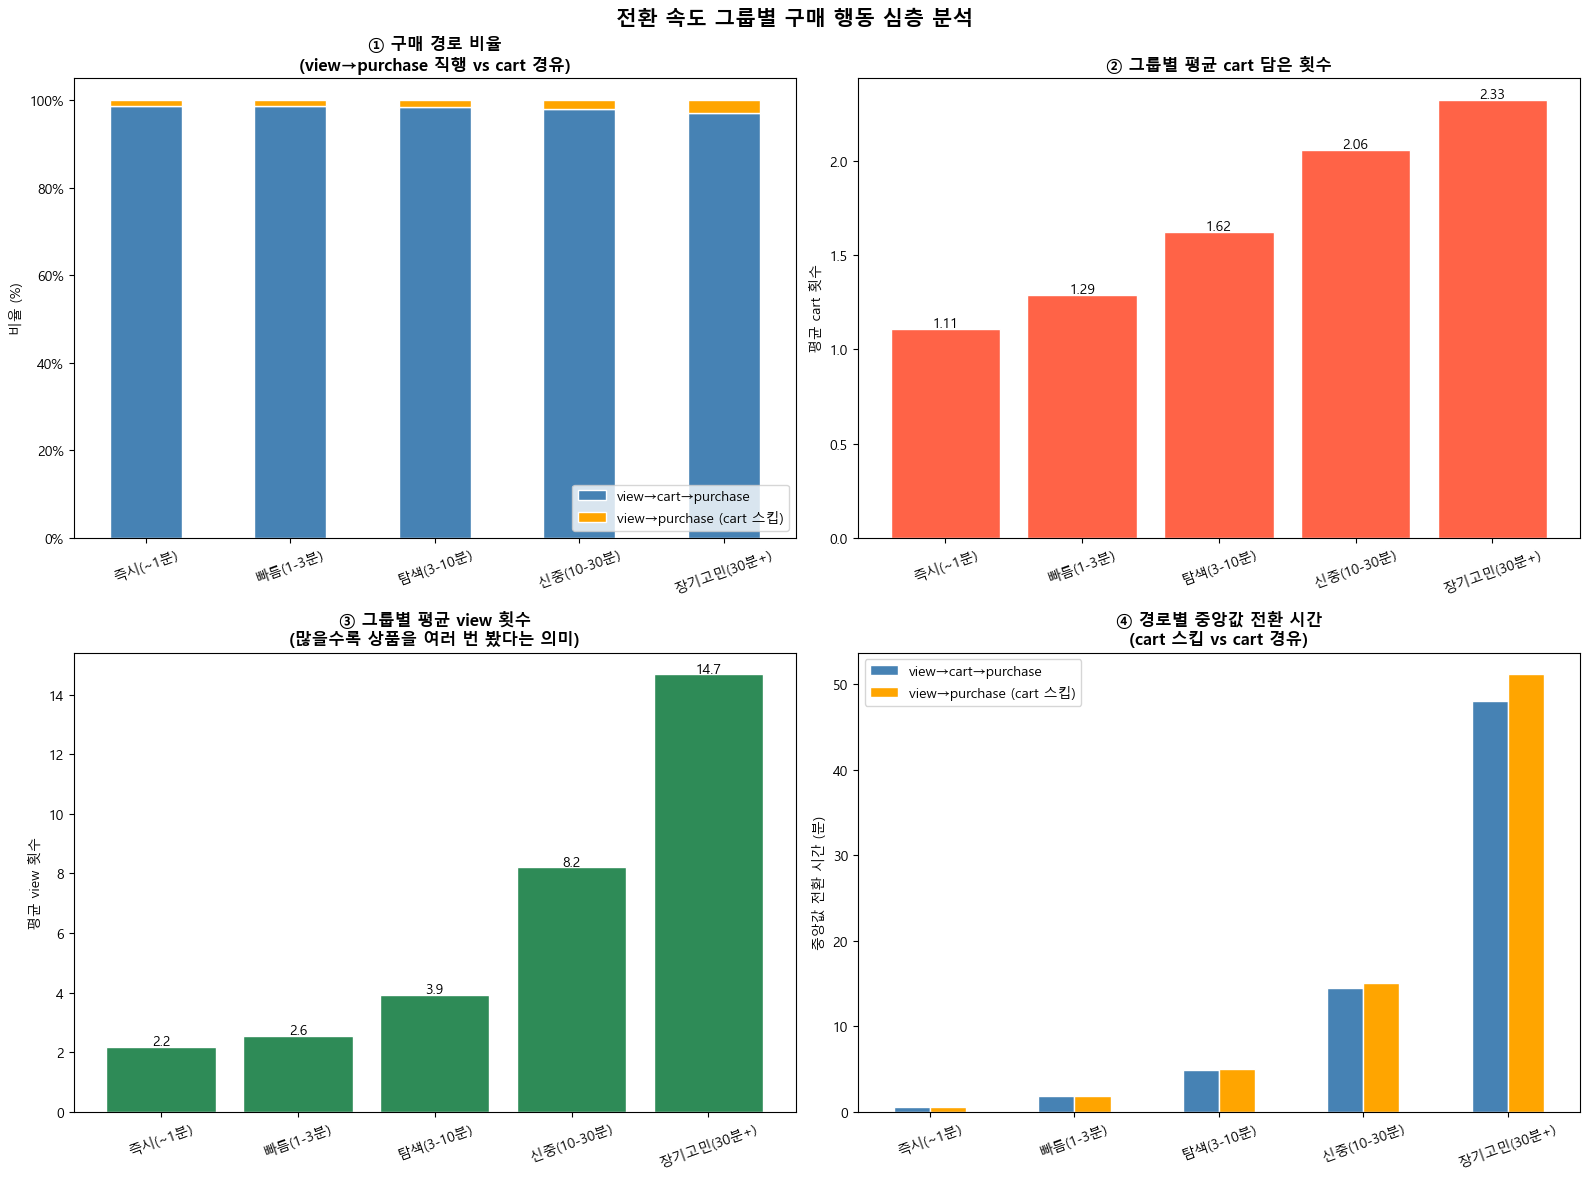

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

labels = ['즉시(~1분)', '빠름(1-3분)', '탐색(3-10분)', '신중(10-30분)', '장기고민(30분+)']

# ① 구매 경로 비율 (cart 스킵 vs cart 경유)
path_ratio = (
    conversion.groupby(['speed_group', 'purchase_path'], observed=True)
    .size()
    .unstack(fill_value=0)
)
path_ratio_pct = path_ratio.div(path_ratio.sum(axis=1), axis=0) * 100

path_ratio_pct.plot(kind='bar', stacked=True, ax=axes[0][0],
                    color=['steelblue', 'orange'], edgecolor='white')
axes[0][0].set_title('① 구매 경로 비율\n(view→purchase 직행 vs cart 경유)', fontweight='bold')
axes[0][0].set_xlabel('')
axes[0][0].set_ylabel('비율 (%)')
axes[0][0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0][0].tick_params(axis='x', rotation=20)
axes[0][0].legend(loc='lower right')

# ② 그룹별 평균 cart 담은 횟수
cart_avg = conversion.groupby('speed_group', observed=True)['cart_count'].mean().reindex(labels)

axes[0][1].bar(labels, cart_avg, color='tomato', edgecolor='white')
axes[0][1].set_title('② 그룹별 평균 cart 담은 횟수', fontweight='bold')
axes[0][1].set_xlabel('')
axes[0][1].set_ylabel('평균 cart 횟수')
axes[0][1].tick_params(axis='x', rotation=20)
for i, v in enumerate(cart_avg):
    axes[0][1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10)

# ③ 그룹별 평균 view 횟수
view_avg = conversion.groupby('speed_group', observed=True)['view_count'].mean().reindex(labels)

axes[1][0].bar(labels, view_avg, color='seagreen', edgecolor='white')
axes[1][0].set_title('③ 그룹별 평균 view 횟수\n(많을수록 상품을 여러 번 봤다는 의미)', fontweight='bold')
axes[1][0].set_xlabel('')
axes[1][0].set_ylabel('평균 view 횟수')
axes[1][0].tick_params(axis='x', rotation=20)
for i, v in enumerate(view_avg):
    axes[1][0].text(i, v + 0.05, f'{v:.1f}', ha='center', fontsize=10)

# ④ cart 스킵 그룹 vs cart 경유 그룹의 평균 전환 시간 비교
path_conv_time = conversion.groupby(['speed_group', 'purchase_path'], observed=True)['conversion_minutes'].median().unstack()

path_conv_time.plot(kind='bar', ax=axes[1][1],
                    color=['steelblue', 'orange'], edgecolor='white')
axes[1][1].set_title('④ 경로별 중앙값 전환 시간\n(cart 스킵 vs cart 경유)', fontweight='bold')
axes[1][1].set_xlabel('')
axes[1][1].set_ylabel('중앙값 전환 시간 (분)')
axes[1][1].tick_params(axis='x', rotation=20)
axes[1][1].legend(loc='upper left')

plt.suptitle('전환 속도 그룹별 구매 행동 심층 분석', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
# =============================================
# 1. 원본 df로 세션 정보 집계
# =============================================
session_info = df.groupby(['user_id', 'user_session']).agg(
    session_start=('event_time', 'min'),
    has_purchase=('event_type', lambda x: (x == 'purchase').any())
).reset_index()

session_info = session_info.sort_values(['user_id', 'session_start'])
session_info['session_rank'] = session_info.groupby('user_id').cumcount() + 1

# =============================================
# 2. 유저별 첫 번째 구매 세션만 추출
# =============================================
first_purchase_session = (
    session_info[session_info['has_purchase']]
    .groupby('user_id')
    .first()
    .reset_index()
)

print(f"전체 유저 수: {first_purchase_session['user_id'].nunique():,}")
print(f"첫 방문 구매: {(first_purchase_session['session_rank'] == 1).sum():,}")
print(f"재방문 구매:  {(first_purchase_session['session_rank'] > 1).sum():,}")

first_purchase_session['visitor_type'] = first_purchase_session['session_rank'].apply(
    lambda x: '첫 방문 구매' if x == 1 else '재방문 구매'
)

# =============================================
# 3. conversion에서 해당 세션만 필터 + visitor_type 합치기
# =============================================
conversion_v2 = conversion[
    conversion.index.isin(first_purchase_session['user_session'])
].copy()

conversion_v2 = conversion_v2.drop(columns=['visitor_type'], errors='ignore')

conversion_v2 = conversion_v2.join(
    first_purchase_session.set_index('user_session')['visitor_type']
)

print(f"\nconversion_v2 세션 수: {len(conversion_v2):,}")
print(f"\nvisitor_type 분포:\n{conversion_v2['visitor_type'].value_counts()}")

전체 유저 수: 192,346
첫 방문 구매: 98,816
재방문 구매:  93,530

conversion_v2 세션 수: 189,501

visitor_type 분포:
visitor_type
첫 방문 구매    97848
재방문 구매     91653
Name: count, dtype: int64



  visitor_type    세션수        평균       중앙값       Q25       Q75
0       재방문 구매  91653  9.156672  3.950000  2.016667  8.150000
1      첫 방문 구매  97848  6.406743  3.283333  1.750000  6.183333


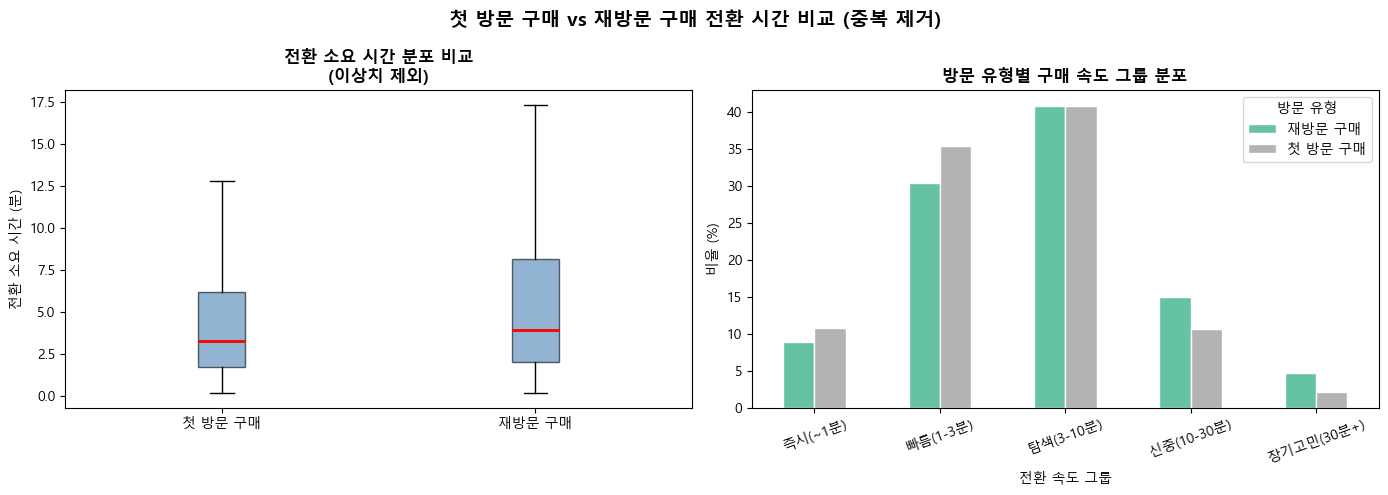

In [42]:
# =============================================
# 4. 통계 요약
# =============================================
visitor_stats = conversion_v2.groupby('visitor_type')['conversion_minutes'].agg(
    세션수='count',
    평균='mean',
    중앙값='median',
    Q25=lambda x: x.quantile(0.25),
    Q75=lambda x: x.quantile(0.75)
).reset_index()
print(f"\n{visitor_stats}")

# =============================================
# 5. 시각화
# =============================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_first  = conversion_v2[conversion_v2['visitor_type'] == '첫 방문 구매']['conversion_minutes'].dropna()
data_return = conversion_v2[conversion_v2['visitor_type'] == '재방문 구매']['conversion_minutes'].dropna()

# 박스플롯
axes[0].boxplot(
    [data_first, data_return],
    labels=['첫 방문 구매', '재방문 구매'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red', linewidth=2),
    showfliers=False
)
axes[0].set_title('전환 소요 시간 분포 비교\n(이상치 제외)', fontweight='bold')
axes[0].set_ylabel('전환 소요 시간 (분)')

# 속도 그룹 분포
speed_visitor = (
    conversion_v2.groupby(['visitor_type', 'speed_group'], observed=True)
    .size()
    .unstack(fill_value=0)
)
speed_visitor_pct = speed_visitor.div(speed_visitor.sum(axis=1), axis=0) * 100
speed_visitor_pct.T.plot(kind='bar', ax=axes[1], edgecolor='white', colormap='Set2')
axes[1].set_title('방문 유형별 구매 속도 그룹 분포', fontweight='bold')
axes[1].set_xlabel('전환 속도 그룹')
axes[1].set_ylabel('비율 (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='방문 유형')

plt.suptitle('첫 방문 구매 vs 재방문 구매 전환 시간 비교 (중복 제거)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()